![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [2]:
!sudo apt-get install libgomp1
!sudo apt-get install libxft2
!sudo apt-get install libglu1

Sudo está deshabilitado en este equipo. Para habilitarlo, vaya a ]8;;ms-settings:developers\Página Configuración del desarrollador]8;;\ en la aplicación Configuración
Sudo está deshabilitado en este equipo. Para habilitarlo, vaya a ]8;;ms-settings:developers\Página Configuración del desarrollador]8;;\ en la aplicación Configuración
Sudo está deshabilitado en este equipo. Para habilitarlo, vaya a ]8;;ms-settings:developers\Página Configuración del desarrollador]8;;\ en la aplicación Configuración


Run everytime you start to execute this Jupyter Notebook

In [100]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [101]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [102]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

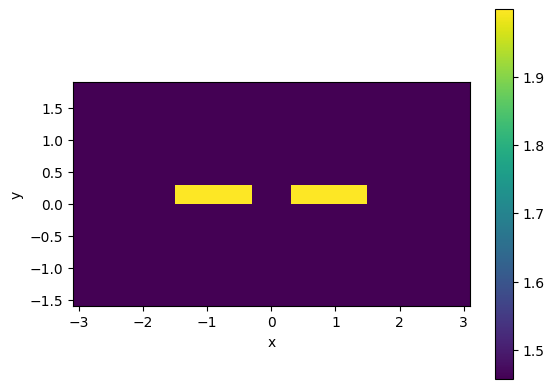

In [103]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [104]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-02 18:17:43.630 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [105]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [106]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

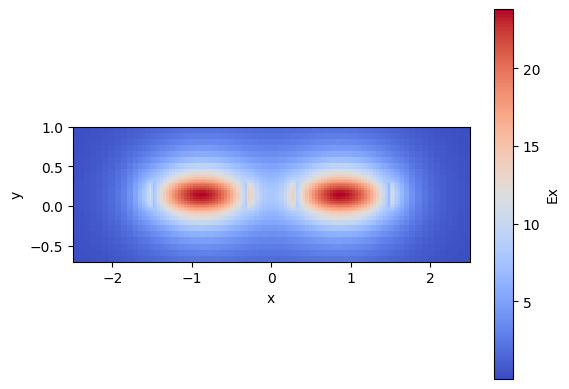

In [107]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

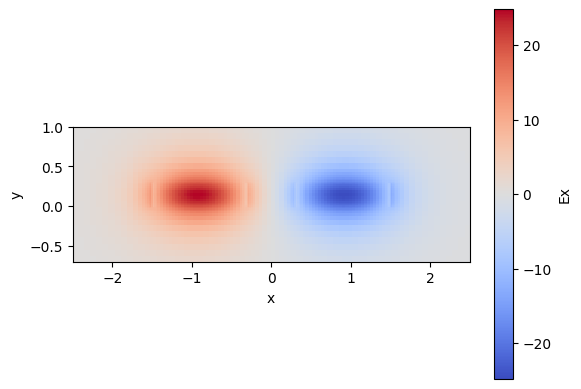

In [108]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

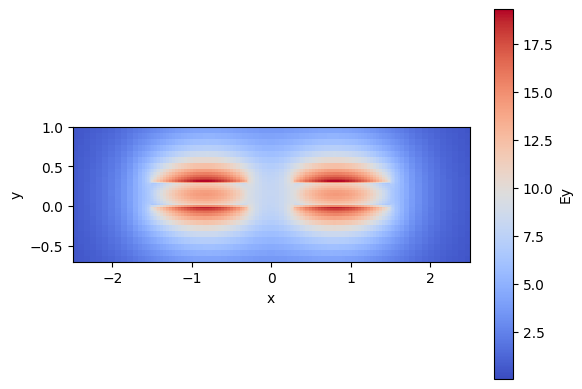

In [109]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

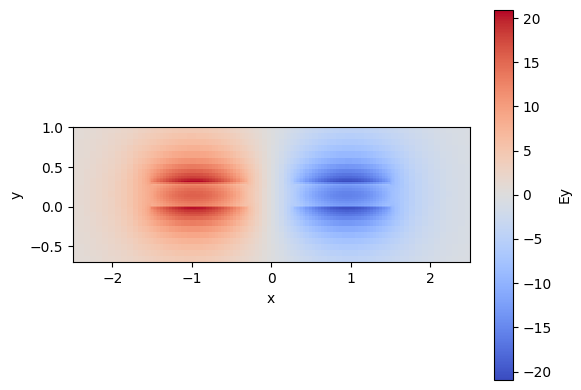

In [110]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [111]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536699239
52.26022367743985


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [112]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

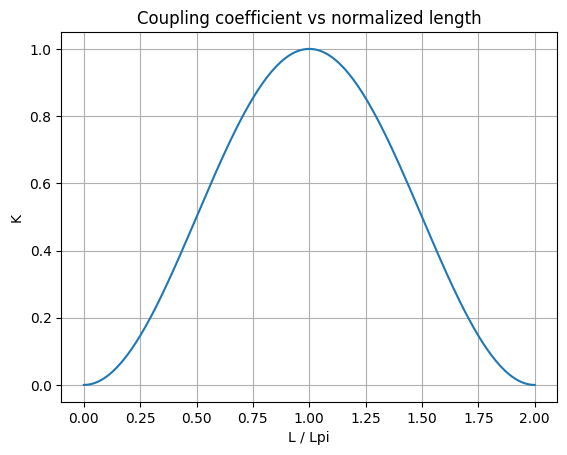

In [113]:
# Evaristo Nicolas Travel - Code LO.2. Directional coupler length and coupling coefficient: 
# Normalized length
L_norm = np.linspace(0, 2, 200)  # L / Lpi

# Coupling coefficient
K = np.sin((np.pi/2) * L_norm)**2

# Plot
plt.figure()
plt.plot(L_norm, K)
plt.xlabel("L / Lpi")
plt.ylabel("K")
plt.title("Coupling coefficient vs normalized length")
plt.grid()
plt.show()

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [114]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605181183  µm


c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


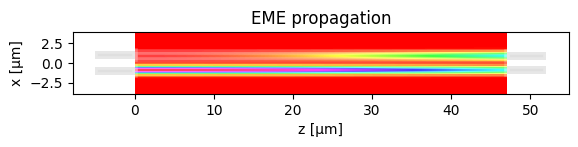

In [115]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  d

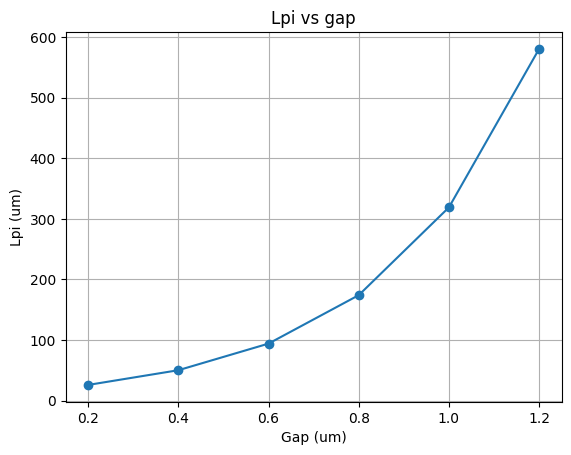

In [116]:
# Evaristo Nicolas Travel - Code LO.3.:
gaps = np.arange(0.2, 1.21, 0.2)

Lpi_list = []

for g in gaps:
    
    m = DC_EME()
    m.MMI_num_modes = 12
    
    m.DC_wg_gap = g
    m.DC_wg_width = 1.2
    m.DC_N_waveguides = 2

    m.find_all_modes()
    
    L_pi = abs(m.get_L_pi())
    Lpi_list.append(L_pi)

# Plot
plt.figure()
plt.plot(gaps, Lpi_list, 'o-')
plt.xlabel("Gap (um)")
plt.ylabel("Lpi (um)")
plt.title("Lpi vs gap")
plt.grid()
plt.show()

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



L_pi requerido para K = 0.01 con L = 10 µm: 156.82 µm
2026-05-02 18:20:09.363 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_19fc40f5ad5a09a8.npz.
2026-05-02 18:20:09.366 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_9c84fee5502c0325.npz.
2026-05-02 18:20:09.370 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_246e538a4cc12806.npz.
2026-05-02 18:20:09.372 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_122f082099186ab3.npz.
2026-05-02 18:20:09.375 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_d02d39a9bd251dd0.npz.
2026-05-02 18:20:09.377 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_7ddad85876e68e81.npz.
2026-05-02 18:20:09.382 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_d0d9c09e512c8fe7.npz.
2026-05-02 18:20:09.38

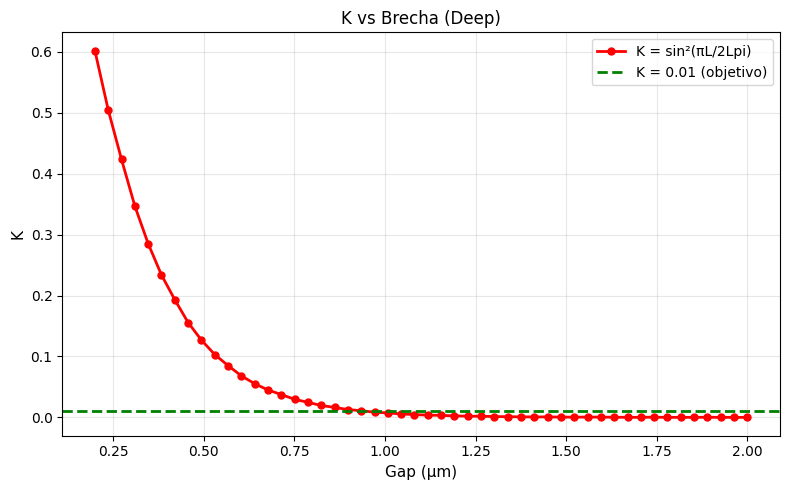


Modo TE0
Brecha mínima para K < 0.01: 0.971 µm
Lpi_required: 156.82 µm
Lpi: 169.36 µm
K: 0.008578


In [117]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

# Evaristo Nicolas Travel - Code LO.4.:
# Objetivo: K < 0.01 con L = 10 mm para el modo TE0
# w = 1.0 µm, λ = 1.55 µm

lambda_c = 1.55  # µm
L_interaction = 10  # µm (10 mm)
K_target = 0.01

# Calcula el L_pi requerido para K = 0.01
# K = sin^2(pi*L/(2*Lpi)) = 0.01
# sin(pi*L/(2*Lpi)) = sqrt(0.01) = 0.1
# pi*L/(2*Lpi) = arcsin(0.1)
# Lpi = pi*L/(2*arcsin(0.1))
L_pi_required = np.pi * L_interaction / (2 * np.arcsin(np.sqrt(K_target)))
print(f"L_pi requerido para K = {K_target} con L = {L_interaction} µm: {L_pi_required:.2f} µm")

gaps_nm = np.linspace(200, 2000, 50)
gaps_um = gaps_nm / 1000

L_pi_values = []
K_values = []

for gap in gaps_um:
    try:
        test_dc = gt.modes.WaveguideCoupler(
            wavelength=lambda_c,
            core_width=(1.0, 1.0),
            gap=gap,
            slab_thickness=0 * nm,
            core_material='sin',
            clad_material='sio2',
            core_thickness=300 * nm,
            num_modes=4,
            cache_path='.cache/',
            precision='double',
            max_grid_scaling=1.5,
            grid_resolution=20
        )
        test_neff = test_dc.n_eff
        L_pi_te = 0.5 * lambda_c / (test_neff[0].real - test_neff[1].real)
        K = np.sin(np.pi * L_interaction / (2 * L_pi_te))**2
        
        L_pi_values.append(L_pi_te)
        K_values.append(K)
        
        if K <= K_target and K >= K_target - 0.005:
            print(f"Brecha = {gap:.3f} µm: Lpi = {L_pi_te:.2f} µm, K = {K:.6f}")
    except:
        pass

plt.figure(figsize=(8, 5))

plt.plot(gaps_um, K_values, 'r-o', linewidth=2, markersize=5, label='K = sin²(πL/2Lpi)')
plt.axhline(y=K_target, color='g', linestyle='--', linewidth=2, label=f'K = {K_target} (objetivo)')

plt.xlabel('Gap (µm)', fontsize=11)
plt.ylabel('K', fontsize=11)
plt.title(f'K vs Brecha (Deep)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Encontrar brecha mínima para K < 0.01
valid_indices = [i for i, k in enumerate(K_values) if k <= K_target]
if valid_indices:
    min_idx = valid_indices[0]
    min_gap = gaps_um[min_idx]
    min_K = K_values[min_idx]
    min_Lpi = L_pi_values[min_idx]
    print(f"\nModo TE0")
    print(f"Brecha mínima para K < {K_target}: {min_gap:.3f} µm")
    print(f"Lpi_required: {L_pi_required:.2f} µm")
    print(f"Lpi: {min_Lpi:.2f} µm")
    print(f"K: {min_K:.6f}")

L_pi requerido para K = 0.01 con L = 10 µm: 156.82 µm
2026-05-02 18:20:14.271 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_8c8eb63846dcafc2.npz.
2026-05-02 18:20:14.275 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_342bc29e30bec45b.npz.
2026-05-02 18:20:14.278 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_de369a2ee73b23ee.npz.
2026-05-02 18:20:14.281 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_32aea8870bb82f35.npz.
2026-05-02 18:20:14.285 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_196356836285fb47.npz.
2026-05-02 18:20:14.288 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_bc94bf2c8757c06b.npz.
2026-05-02 18:20:14.292 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_093078171ac350e2.npz.
2026-05-02 18:20:14.29

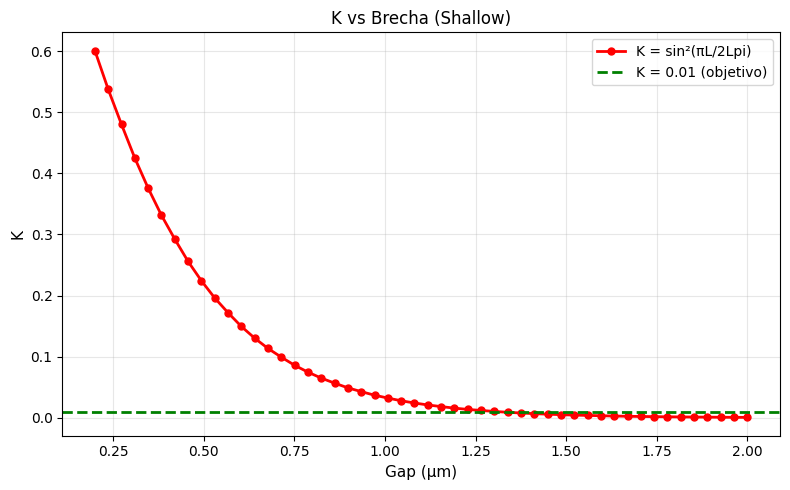


Modo TE0
Brecha mínima para K < 0.01: 1.339 µm
Lpi_required: 156.82 µm
Lpi: 165.13 µm
K: 0.009021


In [118]:
# Evaristo Nicolas Travel - Code LO.4.:
# Objetivo: K < 0.01 con L = 10 mm para el modo TE0
# w = 1.0 µm, λ = 1.55 µm

lambda_c = 1.55  # µm
L_interaction = 10  # µm (10 mm)
K_target = 0.01

# Calcula el L_pi requerido para K = 0.01
# K = sin^2(pi*L/(2*Lpi)) = 0.01
# sin(pi*L/(2*Lpi)) = sqrt(0.01) = 0.1
# pi*L/(2*Lpi) = arcsin(0.1)
# Lpi = pi*L/(2*arcsin(0.1))
L_pi_required = np.pi * L_interaction / (2 * np.arcsin(np.sqrt(K_target)))
print(f"L_pi requerido para K = {K_target} con L = {L_interaction} µm: {L_pi_required:.2f} µm")

# Barre brechas para encontrar la requerida
gaps_nm = np.linspace(200, 2000, 50)
gaps_um = gaps_nm / 1000

L_pi_values = []
K_values = []

for gap in gaps_um:
    try:
        test_dc = gt.modes.WaveguideCoupler(
            wavelength=lambda_c,
            core_width=(1.0, 1.0),
            gap=gap,
            slab_thickness=150 * nm,
            core_material='sin',
            clad_material='sio2',
            core_thickness=300 * nm,
            num_modes=4,
            cache_path='.cache/',
            precision='double',
            max_grid_scaling=1.5,
            grid_resolution=20
        )
        test_neff = test_dc.n_eff
        L_pi_te = 0.5 * lambda_c / (test_neff[0].real - test_neff[1].real)
        K = np.sin(np.pi * L_interaction / (2 * L_pi_te))**2
        
        L_pi_values.append(L_pi_te)
        K_values.append(K)
        
        if K <= K_target and K >= K_target - 0.005:
            print(f"Brecha = {gap:.3f} µm: Lpi = {L_pi_te:.2f} µm, K = {K:.6f}")
    except:
        pass

plt.figure(figsize=(8, 5))

plt.plot(gaps_um, K_values, 'r-o', linewidth=2, markersize=5, label='K = sin²(πL/2Lpi)')
plt.axhline(y=K_target, color='g', linestyle='--', linewidth=2, label=f'K = {K_target} (objetivo)')

plt.xlabel('Gap (µm)', fontsize=11)
plt.ylabel('K', fontsize=11)
plt.title(f'K vs Brecha (Shallow)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Encontrar brecha mínima para K < 0.01
valid_indices = [i for i, k in enumerate(K_values) if k <= K_target]
if valid_indices:
    min_idx = valid_indices[0]
    min_gap = gaps_um[min_idx]
    min_K = K_values[min_idx]
    min_Lpi = L_pi_values[min_idx]
    print(f"\nModo TE0")
    print(f"Brecha mínima para K < {K_target}: {min_gap:.3f} µm")
    print(f"Lpi_required: {L_pi_required:.2f} µm")
    print(f"Lpi: {min_Lpi:.2f} µm")
    print(f"K: {min_K:.6f}")

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [119]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-05-02 18:20:35.407 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [120]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

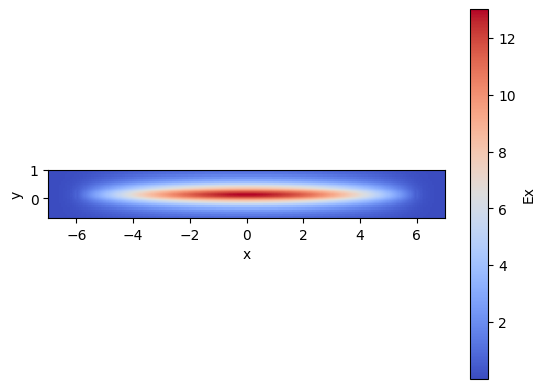

In [121]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

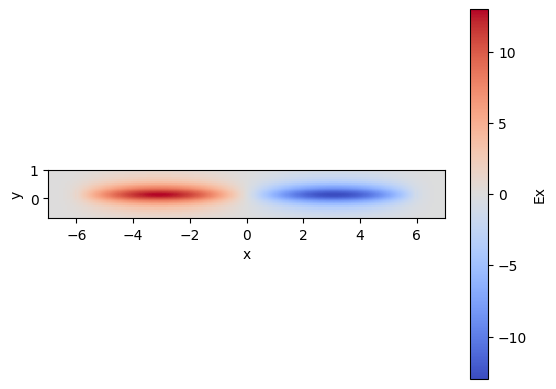

In [122]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

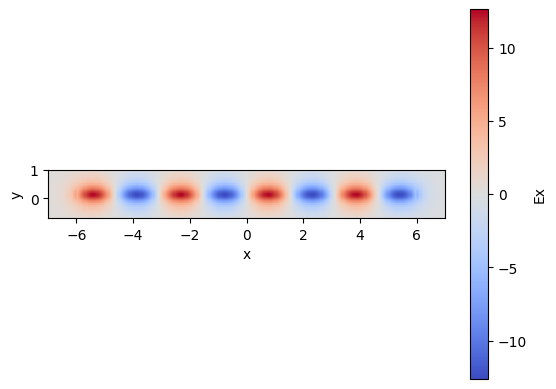

In [123]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [124]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.4111979440746


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [125]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725737  µm


c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


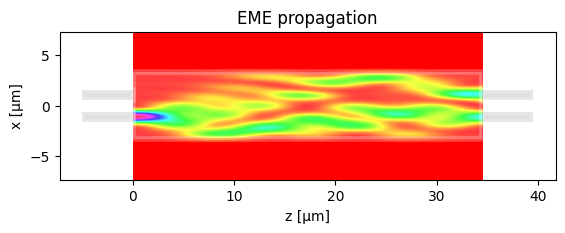

In [126]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9582
Total OUT power: 0.9142
Excess loss [dB] =  0.3897
------------------------
Power over OUTs:  ['0.4633', '0.4509']
Ratio over OUTs ['0.5067', '0.4933']


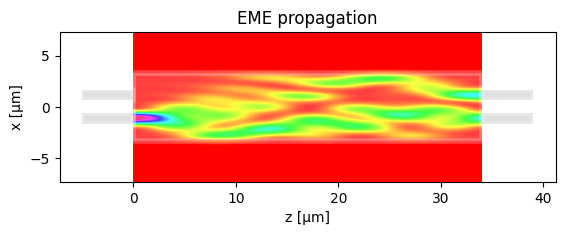

In [167]:
dy = 0.03
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [78]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.6 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255869  µm


c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/685 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.2900
IO wg width 1.0000
IO wg width increment 0.6000
------------------------
Total power IN coupled 0.9894
Total OUT power: 0.9783
Excess loss [dB] =  0.0954
------------------------
Power over OUTs:  ['0.4982', '0.4801']
Ratio over OUTs ['0.5093', '0.4907']


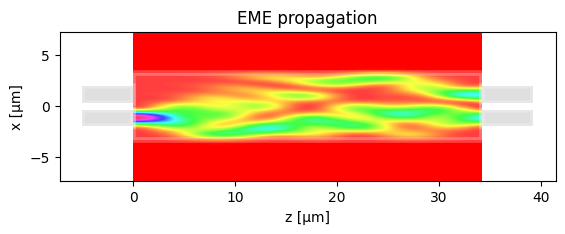

In [79]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.045
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.29

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi = 153.70714915414115 um


c:\Users\enict\Desktop\MUIT\CIFOIN\Practica_2_Cifoin_Enictra\cifoin-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/575 [00:00<?, ?it/s]

------- Pameters -------
MMI length 28.8201
MMI length increment -0.0500
IO wg width 1.0000
IO wg width increment 0.4000
------------------------
Total power IN coupled 0.9866
Total OUT power: 0.9554
Excess loss [dB] =  0.1982
------------------------
Power over OUTs:  ['0.2275', '0.2502', '0.2502', '0.2275']
Ratio over OUTs ['0.2381', '0.2619', '0.2619', '0.2381']


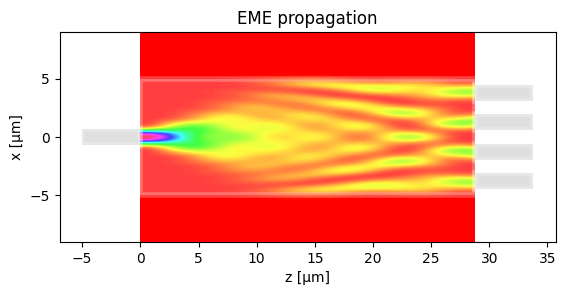

In [ ]:
# Evaristo Nicolas Travel - Code LO.7.:
# MMI
m = MMI_EME()

m.MMI_width = 10.0
m.wg_width_dw = 0.4

# modos
m.find_all_modes()

# Calcular L_pi
L_pi = m.get_L_pi()
print("L_pi =", L_pi, "um")

# 1x4
m.n_IN = 1
m.n_OUT = 4

# outputs
dy = 0.03
m.IN_WVG_positions  = np.array([0]) 

m.OUT_WVG_positions = m.MMI_width * np.array([-3/8, -1/8, 1/8, 3/8]) \
                      + np.array([-dy, -dy, dy, dy])

m.L_MMI = (3/16) * L_pi
m.dL_MMI = -0.05          

m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

In [175]:
# Evaristo Nicolas Travel - Code EXTRA E1 CORREGIDO


### E2. Directional coupler wavelength dependence

In [170]:
# wavelength vector
wavelength = np.linspace(1.5, 1.7, 20) * um

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength,
    core_width=(1.0, 1.0),
    gap=600 * nm,
    slab_thickness=0 * nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20
)

deep_neff = deep_dcoupler_cs.n_eff

# Lpi TE
d_neff = np.real(deep_neff[:,0] - deep_neff[:,1])
L_pi_TE = 0.5 * wavelength / d_neff

18:43:22 Hora de verano romance WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (169259246959034.88, 
                                1208994621135963.5)                             

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

...

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (169259246959034.88, 
                                1208994621135963.5)                             

                                ERROR: 'RectangularDielectric' can only be used 
                                with dielectric media. Found a conductor with   
                                real permittivity < 1.                          

ValidationError: 1 validation error for RectangularDielectric
clad_medium
  'RectangularDielectric' can only be used with dielectric media. Found a conductor with real permittivity < 1. (type=value_error.validation)

### E3. MMI coupler wavelength dependence

In [171]:
mmi_body_w = 6.6

# wavelength vector
lambda_c = np.linspace(1.5, 1.7, 20) * um

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical parameters
    core_width=mmi_body_w,
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    # Materials
    core_material='sin',
    clad_material='sio2',
    # Modesolver Parameters
    wavelength=lambda_c,
    num_modes=15,
    max_grid_scaling=1.5,
    grid_resolution=20,
    cache_path='.cache/',
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real - mmi_body_waveguide.n_eff[1].real

# Lpi
L_pi = 0.5 * lambda_c / d_n_eff

# Plot
plt.plot(lambda_c / um, L_pi / um, 'o-')
plt.xlabel('wavelength (um)')
plt.ylabel('L_pi (um)')
plt.grid()
plt.title('MMI wavelength dependence (deep)')
plt.show()

18:43:28 Hora de verano romance WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (169259246959034.88, 
                                1208994621135963.5)                             

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

...

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (169259246959034.88, 
                                1208994621135963.5)                             

18:43:29 Hora de verano romance ERROR: 'RectangularDielectric' can only be used 
                                with dielectric media. Found a conductor with   
                                real permittivity < 1.                          

ValidationError: 1 validation error for RectangularDielectric
clad_medium
  'RectangularDielectric' can only be used with dielectric media. Found a conductor with real permittivity < 1. (type=value_error.validation)

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55 * um

# sweep de anchura
widths = np.arange(5.0, 10.5, 0.5)

Lpi_list = []

for mmi_body_w in widths:

    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=300 * nm,
        slab_thickness=0 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=15,
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )

    neff = mmi_body_waveguide.n_eff

    d_neff = np.real(neff[0] - neff[1])

    L_pi = 0.5 * lambda_c / d_neff

    Lpi_list.append(L_pi / um)

# plot
plt.plot(widths, Lpi_list, 'o-')
plt.xlabel('MMI width (um)')
plt.ylabel('L_pi (um)')
plt.grid()
plt.show()

18:44:55 Hora de verano romance WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (169259246959034.88, 
                                1208994621135963.5)                             

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (152024573088740.38, 
                                724311326723836.8)                              

                                WARNING: frequency passed to                    
                                'Medium.eps_model()'is outside of               
                                'Medium.frequency_range' = (169259246959034.88, 
                                1208994621135963.5)                             

                                ERROR: 'RectangularDielectric' can only be used 
                                with dielectric media. Found a conductor with   
                                real permittivity < 1.                          

ValidationError: 1 validation error for RectangularDielectric
clad_medium
  'RectangularDielectric' can only be used with dielectric media. Found a conductor with real permittivity < 1. (type=value_error.validation)

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points